<center><h1> Predictive Targeting in Bank Marketing Campaigns using Deep Learning Architectures and Big Data</h1></center>

In [2]:
# Install Packages
# !python3 -m pip install ucimlrepo

In [2]:
# Import Packages
import numpy as np
import pandas as pd
import seaborn as sns
import json
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# Import Dataset
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 
  
X['target']=y
X.to_csv('marketing_data.csv')
# variable information 
print(bank_marketing.variables) 

           name     role         type      demographic  \
0           age  Feature      Integer              Age   
1           job  Feature  Categorical       Occupation   
2       marital  Feature  Categorical   Marital Status   
3     education  Feature  Categorical  Education Level   
4       default  Feature       Binary             None   
5       balance  Feature      Integer             None   
6       housing  Feature       Binary             None   
7          loan  Feature       Binary             None   
8       contact  Feature  Categorical             None   
9   day_of_week  Feature         Date             None   
10        month  Feature         Date             None   
11     duration  Feature      Integer             None   
12     campaign  Feature      Integer             None   
13        pdays  Feature      Integer             None   
14     previous  Feature      Integer             None   
15     poutcome  Feature  Categorical             None   
16            

In [6]:
X

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN


In [7]:
y

,y
0,no
1,no
2,no
3,no
4,no
...,...
45206,yes
45207,yes
45208,yes
45209,no


## Data Preparation

In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
dtypes: int64(7), object(9)
memory usage: 5.5+ MB


In [9]:
X.isnull().sum()

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
dtype: int64

In [34]:
try:
    df = X.copy()
    df['target']=y # add target column to delete same rows if a record is empty
    df.drop(columns=['poutcome'], inplace=True)
    df.dropna(axis=1, inplace=True)
    y = df['target']
    X = df.drop(columns=['target'])
except:
    print('No changes made in the dataset.')

X.isnull().sum()

df.to_csv('marketing_data.csv')

No changes made in the dataset.


## Data Visualization

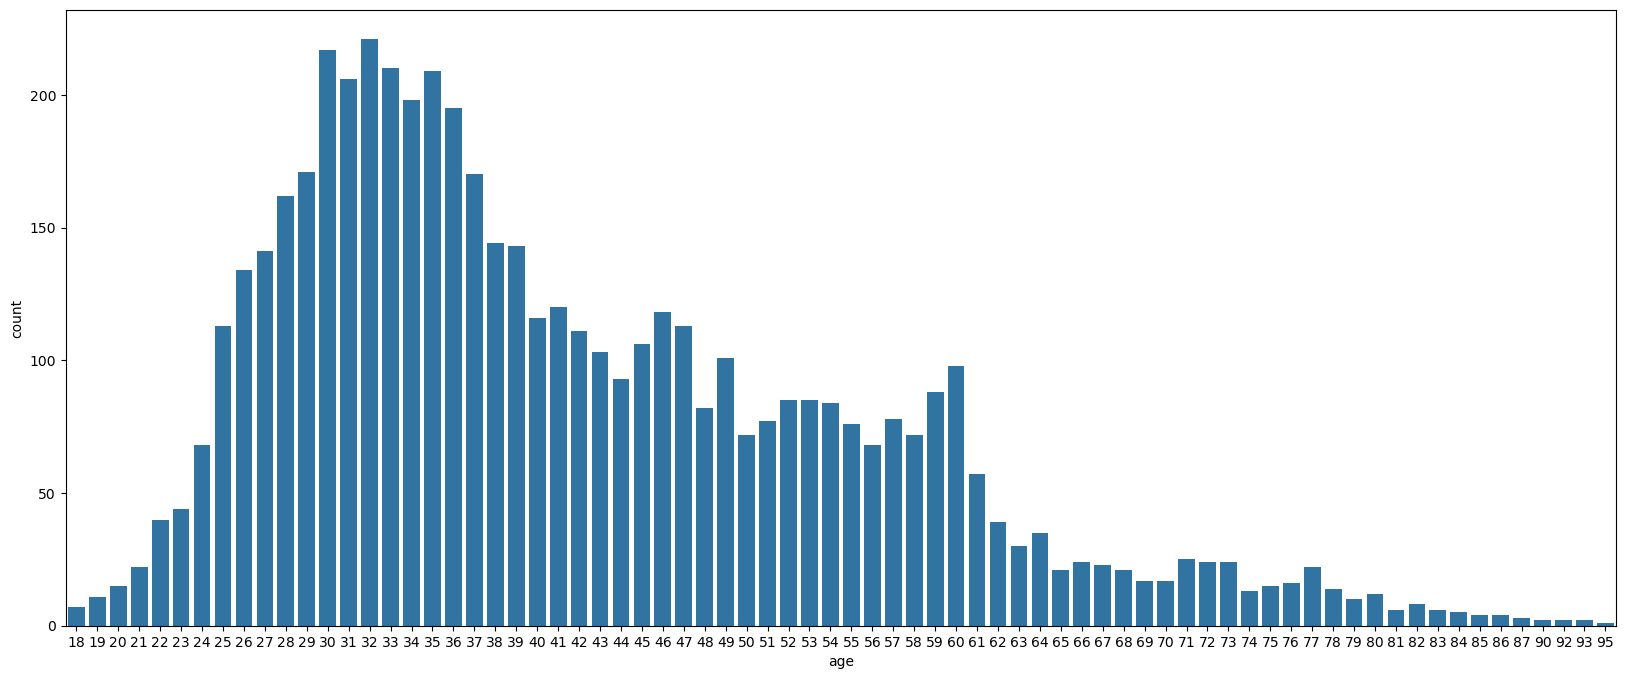

In [17]:
df_yes = df.loc[df.target == 'yes']

plt.figure(figsize=(20,8))
sns.countplot(x="age", data=df_yes)
plt.show()

In [18]:
## Get sample data and compare % of female and male 

## Machine Learning

In [24]:
def label_encoder_df(df):
    df_encoded = df.copy()
    le = LabelEncoder()
    for col in df_encoded.select_dtypes(include=["object"]).columns:
        df_encoded[col] = le.fit_transform(df_encoded[col])
    return df_encoded

X_encoded = label_encoder_df(X)
y_df = y.to_frame() 
y_encoded = label_encoder_df(y_df)
print(X_encoded.head(),'\n', y_encoded.head())

   age  marital  default  balance  housing  loan  day_of_week  month  \
0   58        1        0     2143        1     0            5      8   
1   44        2        0       29        1     0            5      8   
2   33        1        0        2        1     1            5      8   
3   47        1        0     1506        1     0            5      8   
4   33        2        0        1        0     0            5      8   

   duration  campaign  pdays  previous  
0       261         1     -1         0  
1       151         1     -1         0  
2        76         1     -1         0  
3        92         1     -1         0  
4       198         1     -1         0   
    target
0       0
1       0
2       0
3       0
4       0


In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [26]:
X_scaled

array([[ 1.60696496, -0.27576178, -0.13548989, ..., -0.56935064,
        -0.41145311, -0.25194037],
       [ 0.28852927,  1.3683719 , -0.13548989, ..., -0.56935064,
        -0.41145311, -0.25194037],
       [-0.74738448, -0.27576178, -0.13548989, ..., -0.56935064,
        -0.41145311, -0.25194037],
       ...,
       [ 2.92540065, -0.27576178, -0.13548989, ...,  0.72181052,
         1.43618859,  1.05047333],
       [ 1.51279098, -0.27576178, -0.13548989, ...,  0.39902023,
        -0.41145311, -0.25194037],
       [-0.37068857, -0.27576178, -0.13548989, ..., -0.24656035,
         1.4761376 ,  4.52357654]])

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,         
    test_size=0.2, 
    random_state=42,  
    stratify=y     
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((36168, 12), (36168, 1), (9043, 12), (9043, 1))

In [28]:
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'), 
    Dense(32, activation='relu'),                               
    Dense(1, activation='sigmoid')                             
])

model.compile(
    optimizer='adam', 
    loss='binary_crossentropy',  # binary classification
    metrics=['accuracy']
)

/home/hduser/.local/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
early_stop = EarlyStopping(
    monitor='val_loss',  
    patience=10,          
    restore_best_weights=True  
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=100,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8848 - loss: 0.3016 - val_accuracy: 0.8909 - val_loss: 0.2547
Epoch 2/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8934 - loss: 0.2537 - val_accuracy: 0.8916 - val_loss: 0.2466
Epoch 3/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8944 - loss: 0.2475 - val_accuracy: 0.8970 - val_loss: 0.2433
Epoch 4/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8959 - loss: 0.2437 - val_accuracy: 0.8969 - val_loss: 0.2407
Epoch 5/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8962 - loss: 0.2414 - val_accuracy: 0.8962 - val_loss: 0.2388
Epoch 6/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8960 - loss: 0.2391 - val_accuracy: 0.8969 - val_loss: 0.2394
Epoch 7/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8958 - loss: 0.2376 - val_accuracy: 0.8974 - val_loss: 0.2388
Epoch 8/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8975 - loss: 0.2358 - val_accuracy: 0.

In [30]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8946 - loss: 0.2375
Test Accuracy: 89.46%


In [31]:
result = model.predict(X_test)

rounded = [round(x[0]) for x in result]
print(rounded)

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step
[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

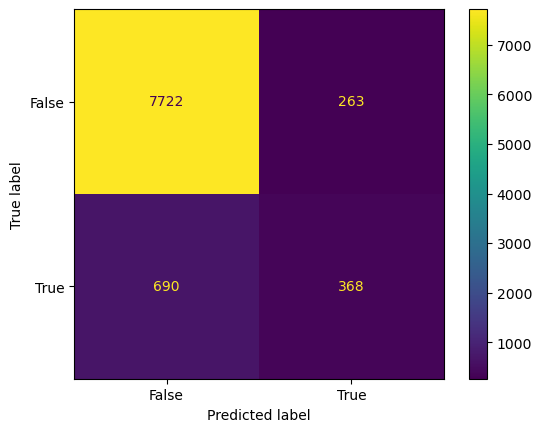

In [32]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

actual = y_test
predicted = rounded

confusion_matrix = metrics.confusion_matrix(actual, rounded)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.show() 